# 05 Site explorer and the reactive sign convention

Two jobs:

1. **Unpack individual sites** — daily operational plots in the style of
   `ausgrid_analysis/notebooks/02c_explore_voltvar_voltwatt`, plus per-site Volt-VAr
   curves against the AS/NZS 4777.2 requirement.
2. **Settle the reactive sign**, fleet-wide, with every step showing whether the number
   on screen is the **raw delivered** value or the **flipped stored** one.

## Sign provenance — read this before any plot

Two orientations exist, and every function here carries both:

| column | meaning |
|---|---|
| `Q_raw_var` | straight from the delivered Parquet, **nothing applied** |
| `Q_raw_kvar` | `Q_raw_var / 1000` — sign still untouched |
| `Q_stored_kvar` | what `se_interval` holds, and what D9/D10 scored: `-1 × raw / 1000` |

Active power is **not** transformed. `ACTIVE_POWER_SIGN = +1`, SolarEdge reports a
production magnitude, and there are no negative values anywhere in the delivery.

Every figure stamps its orientation in the title. If it says `STORED`, the flip is
applied. If it says `RAW`, it is as SolarEdge delivered it.

In [32]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

_current = Path.cwd().resolve()
REPO_ROOT = next(
    (p for p in (_current, *_current.parents)
     if (p / "solar_edge").is_dir() and (p / "bms_sa_review").is_dir()),
    None,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from solar_edge.config import se_config as C
from solar_edge.lib import se_store, se_explore as ex, se_sign as sign

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)

con = se_store.connect()
print(f"REACTIVE_POWER_SIGN = {C.REACTIVE_POWER_SIGN:+.0f}   "
      f"(stored Q = {C.REACTIVE_POWER_SIGN:+.0f} x raw / 1000)")
print(f"ACTIVE_POWER_SIGN   = {C.ACTIVE_POWER_SIGN:+.0f}   (no change)")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
REACTIVE_POWER_SIGN = +1   (stored Q = +1 x raw / 1000)
ACTIVE_POWER_SIGN   = +1   (no change)


## 1. Verify the transform against the raw files

Before arguing about which orientation is correct, confirm what the store actually did.

This re-reads the delivered Parquet for one site, re-applies the timezone conversion
independently, joins on the UTC instant, and checks that
`Q_stored_kvar == -1 × Q_raw_var / 1000` on every row. It also checks active power was
left alone.

If `n_Q_mismatched` is anything but 0, stop — the store is not what the rest of this
notebook assumes.

In [125]:
SITE = "AUS1408"        
display(ex.verify_sign_transform(con, SITE).T)
display(ex.site_profile(con, SITE))

,0
n_compared,53718
expected_Q_rule,+1 x raw / 1000
n_Q_mismatched,0.0
max_Q_abs_diff,0.0
expected_P_rule,+1 x raw / 1000
n_P_mismatched,0.0


site_alias                              AUS1408
state                           New South Wales
postcode                                   2335
n_phases                                      1
is_three_phase                            False
n_intervals                               53718
n_days_observed                             365
has_night_generation_anomaly              False
s_99                                       4.85
p_99                                       4.85
pct_derating                             20.269
med_Q_stored_above_250                   0.2324
med_Q_stored_deadband                    0.2264
Name: 0, dtype: object

## 2. The per-site curve — which orientation matches the standard?

Median Q against voltage for one site, drawn **both ways**, with the required curve and
its ±4% tolerance band in magenta.

The question the plot asks: *which trace sits on the same side of zero as the
requirement, and inside its tolerance band?*

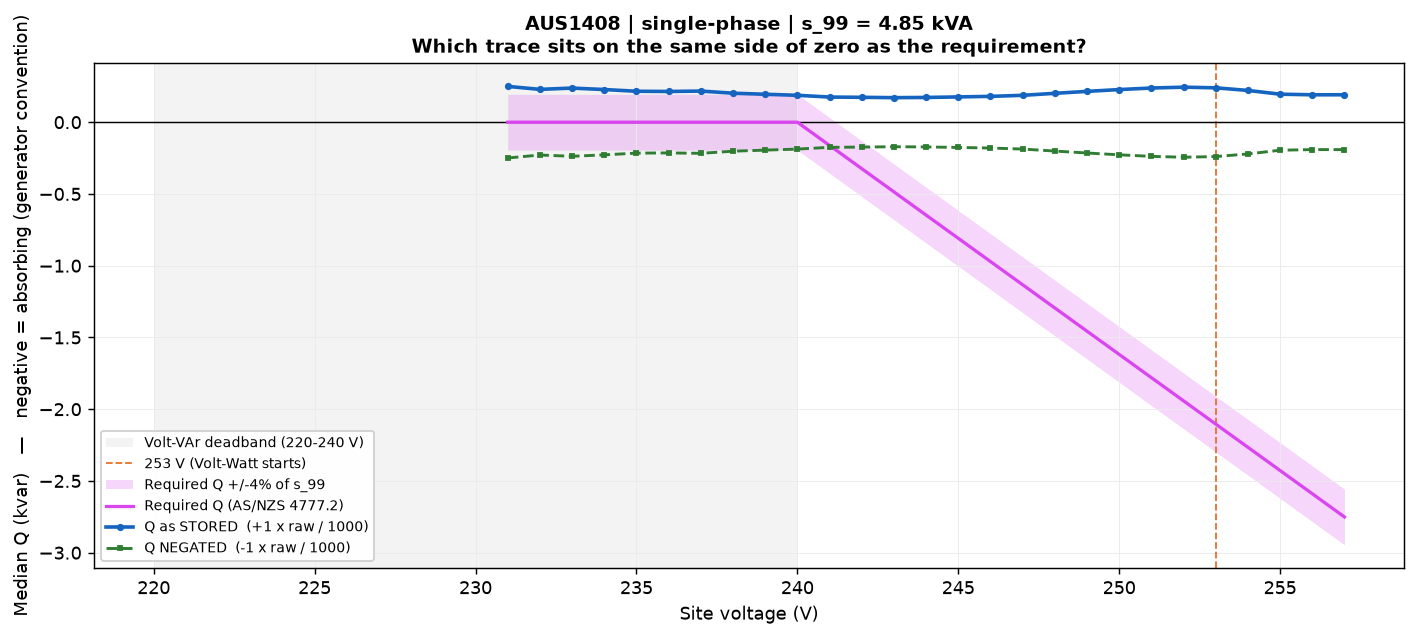

,v_bin,n_intervals,Q_stored_kvar,Q_flipped_kvar,Q_raw_var,P_kW,s_99
0,231.0,20,0.2494,-0.2494,-249.399994,0.452,4.854614
1,232.0,35,0.2287,-0.2287,-228.699997,0.426,4.854614
2,233.0,60,0.2377,-0.2377,-237.699997,0.573,4.854614
3,234.0,87,0.2276,-0.2276,-227.600006,0.552,4.854614
4,235.0,120,0.2156,-0.2156,-215.600006,0.484,4.854614
5,236.0,204,0.2141,-0.2141,-214.100006,0.533,4.854614
6,237.0,285,0.2169,-0.2169,-216.899994,0.621,4.854614
7,238.0,413,0.2021,-0.2021,-202.100006,0.544,4.854614
8,239.0,587,0.1946,-0.1946,-194.600006,0.587,4.854614
9,240.0,1081,0.1874,-0.1874,-187.399994,0.612,4.854614


In [126]:
curve = ex.site_voltvar_curve(con, SITE)
display(ex.plot_site_voltvar_curve(curve, SITE, ex.site_profile(con, SITE)))
display(curve.head(12));

## 3. The daily operational plot

Five panels — voltage, active power, Volt-Watt non-conformance, reactive power, Volt-VAr
non-conformance — ported from `plot_operational_ausgrid`.

`site_days_available()` ranks days by how much time they spend above 240 V, because a day
that never enters the Volt-VAr band shows a flat reactive trace and settles nothing.

Both orientations are plotted below. **Compare the fourth panel**: the blue measured
trace against the magenta required band.

In [127]:
days = ex.site_days_available(con, SITE)
display(days.head(8))
days

,day_aest,n_intervals,n_above_240,n_above_253,max_V,max_P_kW,max_abs_Q_kvar
0,2025-12-29,175,175,55,256.500000,4.44,0.280
1,2025-12-30,175,175,71,256.399994,4.72,0.270
2,2025-12-17,175,175,41,255.500000,4.56,0.263
3,2025-12-27,175,175,68,257.399994,4.11,0.250
4,2025-12-28,175,175,39,257.200012,3.94,0.228
5,2025-01-10,174,174,14,255.300003,4.96,0.273
6,2025-12-03,174,174,93,258.000000,4.05,0.267
7,2025-12-31,174,174,17,255.300003,3.79,0.203


,day_aest,n_intervals,n_above_240,n_above_253,max_V,max_P_kW,max_abs_Q_kvar
0,2025-12-29,175,175,55,256.500000,4.44,0.280
1,2025-12-30,175,175,71,256.399994,4.72,0.270
2,2025-12-17,175,175,41,255.500000,4.56,0.263
3,2025-12-27,175,175,68,257.399994,4.11,0.250
4,2025-12-28,175,175,39,257.200012,3.94,0.228
...,...,...,...,...,...,...,...
358,2025-08-20,132,51,0,244.300003,2.43,0.257
359,2025-08-21,131,51,0,245.300003,2.10,0.242
360,2025-08-03,128,40,0,252.500000,4.44,0.227
361,2025-09-11,141,38,0,244.399994,1.66,0.240


In [128]:
ZOOM_DATE = str(days.day_aest.iloc[2])[:10]
# ZOOM_DATE = "2025-04-16"     # override with any date from days.day_aest
# ZOOM_DATE = "2025-04-16"

df_day = ex.site_day(con, SITE, ZOOM_DATE)
assert len(df_day) > 0, f"No rows for {ZOOM_DATE}"
print(f"{len(df_day)} intervals | raw values joined: {df_day.Q_raw_var.notna().sum()}")
display(df_day[["ts_aest", "V", "P_kW", "Q_raw_var", "Q_raw_kvar", "Q_stored_kvar"]].iloc[::24])

175 intervals | raw values joined: 175


,ts_aest,V,P_kW,Q_raw_var,Q_raw_kvar,Q_stored_kvar
0,2025-12-17 04:44:36,248.979355,0.000000,0.000000,0.000000,0.000000
24,2025-12-17 06:44:36,249.668427,1.326752,155.837662,0.155838,0.155838
48,2025-12-17 08:44:36,249.186111,1.905714,209.954163,0.209954,0.209954
72,2025-12-17 10:44:37,247.712784,2.289120,165.075745,0.165076,0.165076
96,2025-12-17 12:44:37,253.692734,3.984148,235.563156,0.235563,0.235563
120,2025-12-17 14:44:37,250.729202,4.440675,253.822769,0.253823,0.253823
144,2025-12-17 16:44:37,243.371536,2.330970,217.207275,0.217207,0.217207
168,2025-12-17 18:44:37,242.267731,0.030615,197.625824,0.197626,0.197626


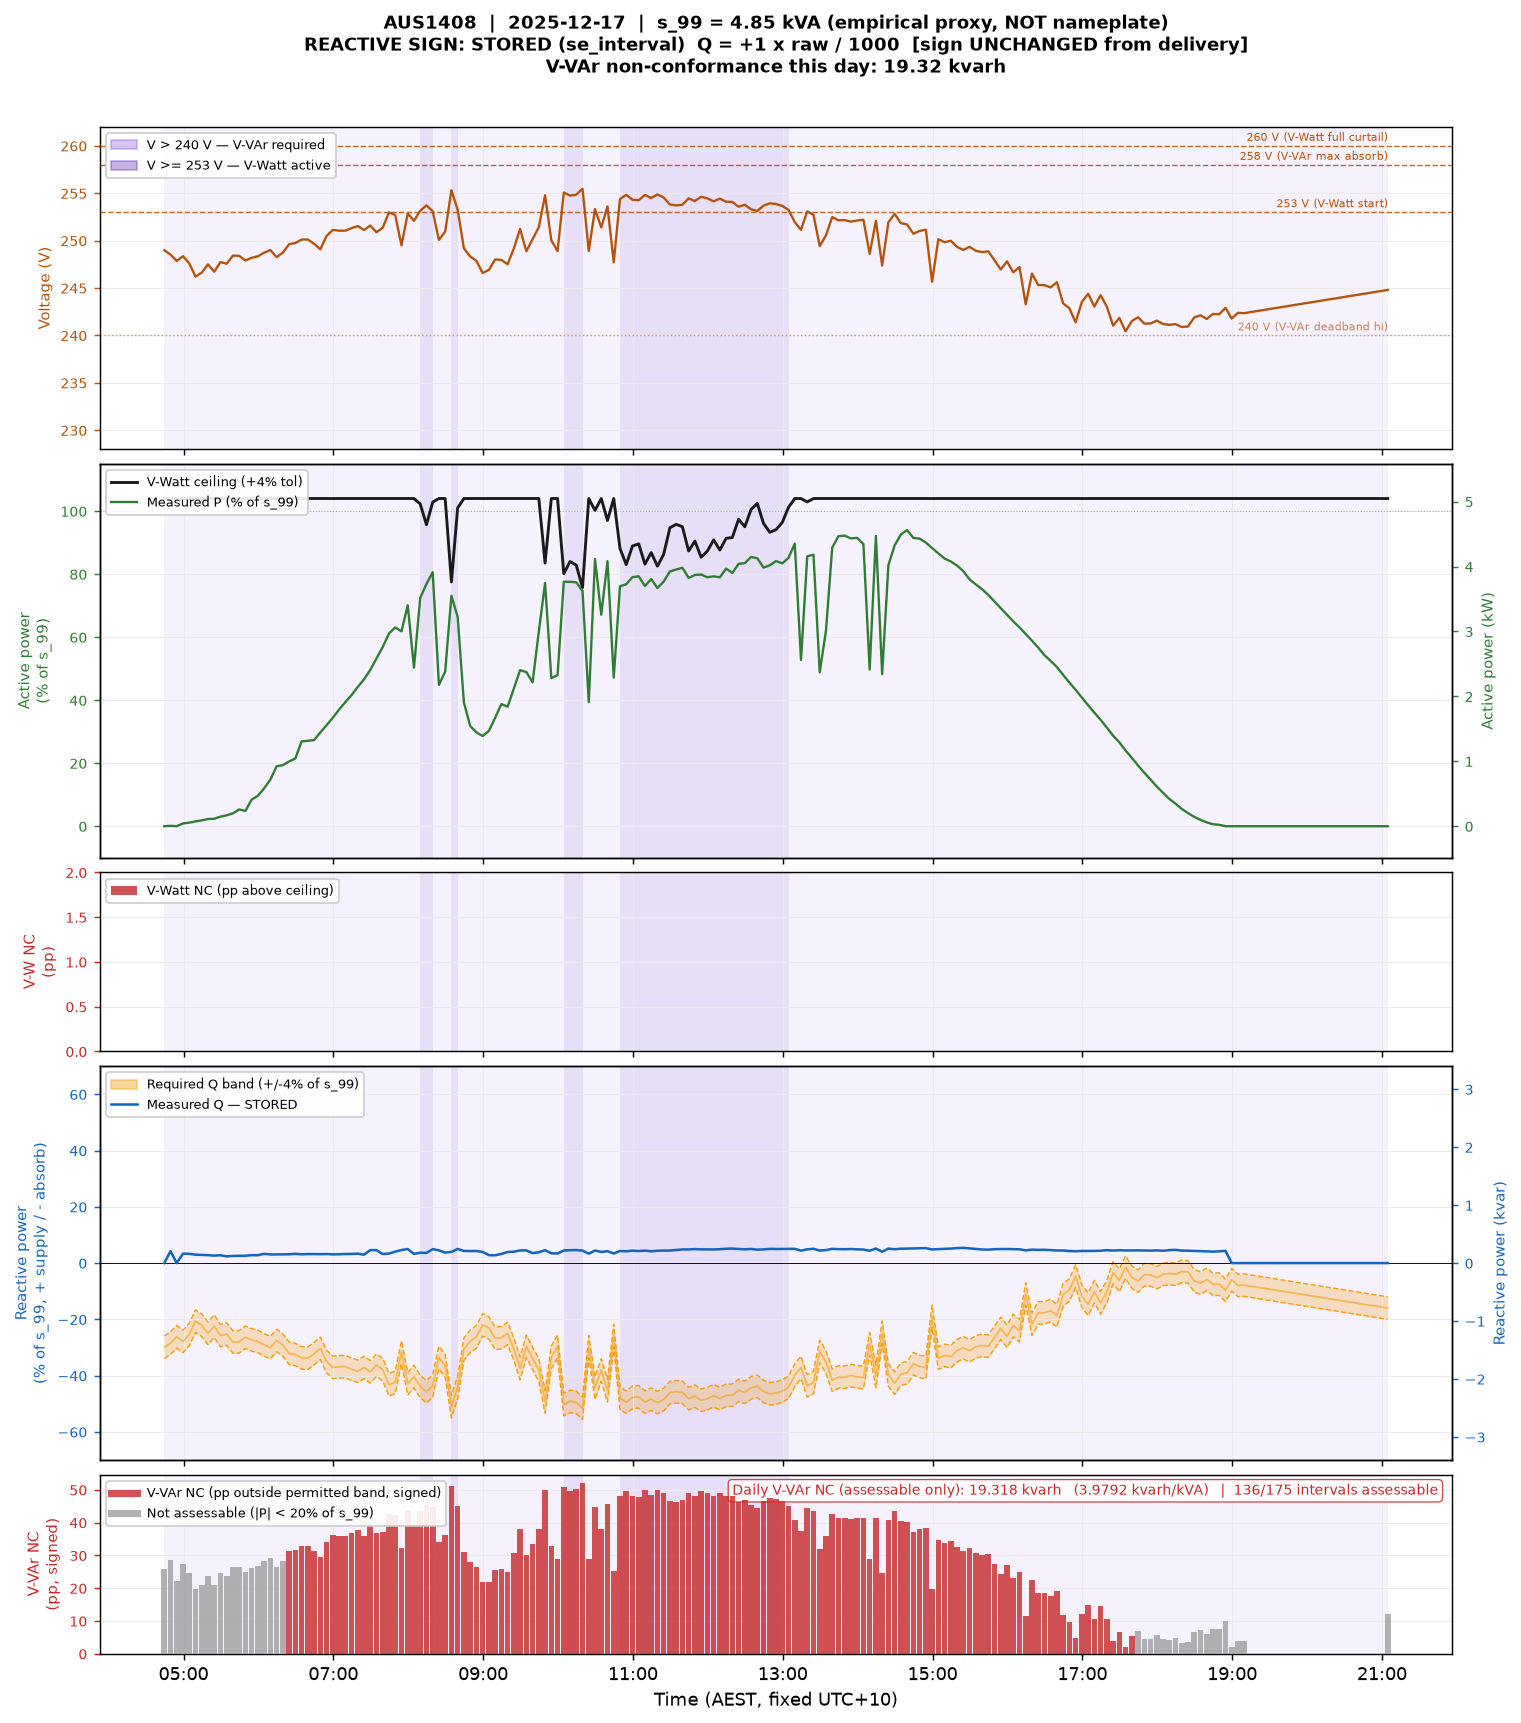

In [129]:
S = float(df_day.s_99.iloc[0])
display(ex.plot_operational(df_day, SITE, S, ZOOM_DATE, orientation="stored"))

In [130]:
cats = ex.site_interval_categories(con, SITE, ZOOM_DATE)
display(cats.category.value_counts().rename("intervals").to_frame())
display(cats[["ts_aest", "V", "P_kW", "Q_kvar", "Q_min_permitted", "Q_max_permitted",
              "Q_impact", "category", "dist_to_band_kvar"]])

,intervals
category,
Q_adverse,113
not_assessable,39
Q_inactive,21
Q_major_surplus,2


,ts_aest,V,P_kW,Q_kvar,Q_min_permitted,Q_max_permitted,Q_impact,category,dist_to_band_kvar
0,2025-12-17 04:44:36,248.979996,0.000,0.0000,-1.6472,0.1942,NaN,not_assessable,0.0
1,2025-12-17 04:49:36,248.529999,0.006,0.2057,-1.5746,0.1942,NaN,not_assessable,0.0
2,2025-12-17 04:54:36,247.860001,0.000,0.0000,-1.4658,0.1942,NaN,not_assessable,0.0
3,2025-12-17 04:59:36,248.360001,0.044,0.1630,-1.5474,0.1942,NaN,not_assessable,0.0
4,2025-12-17 05:04:36,247.610001,0.055,0.1598,-1.4257,0.1942,NaN,not_assessable,0.0
...,...,...,...,...,...,...,...,...,...
170,2025-12-17 18:54:37,242.910004,0.000,0.2105,-0.6652,0.1942,NaN,not_assessable,0.0
171,2025-12-17 18:59:37,241.779999,0.000,0.0000,-0.4815,0.1942,NaN,not_assessable,0.0
172,2025-12-17 19:04:37,242.389999,0.000,0.0000,-0.5805,0.1942,NaN,not_assessable,0.0
173,2025-12-17 19:09:37,242.350006,0.000,0.0000,-0.5748,0.1942,NaN,not_assessable,0.0


## 4. Fleet-wide: which orientation fits the required curve?

Not a sample — **every site in the fleet**.

For each site, across the Volt-VAr ramp only (241–253 V, where the requirement is
non-zero and Volt-Watt has not yet engaged), compute the median absolute deviation of
measured Q from the required curve in both orientations, and compare against the ±4%
tolerance band.

Three outcomes:

- **`raw fits`** — as-delivered is within tolerance, flipped is not. The flip broke it.
- **`stored fits`** — the reverse. The flip was right for this site.
- **`neither fits`** — the site is not following the curve either way, so it carries no
  information about the convention and should be excluded from the argument.

In [ ]:
'''
fit = sign.fleet_orientation_fit(con)
print(f"{len(fit):,} of 1,602 sites had enough data in the ramp\n")
display(pd.crosstab(fit.cohort, fit.verdict, margins=True))

informative = fit[fit.verdict.str.contains(r"fits \(within")]
print(f"\nInformative sites (fit exactly one orientation): {len(informative):,}")
display(pd.crosstab(informative.cohort, informative.verdict))

fit.to_csv(C.ARTEFACT_DIR / "fleet_orientation_fit.csv", index=False)
print(f"\nFull per-site table -> {C.ARTEFACT_DIR / 'fleet_orientation_fit.csv'}")
'''

1,590 of 1,602 sites had enough data in the ramp



verdict,neither fits,raw fits (within tol),stored fits (within tol),All
cohort,,,,
single-phase,945,105,126,1176
three-phase,327,1,86,414
All,1272,106,212,1590



Informative sites (fit exactly one orientation): 318


verdict,raw fits (within tol),stored fits (within tol)
cohort,,
single-phase,105,126
three-phase,1,86



Full per-site table -> C:\Users\z3553082\OneDrive - UNSW\Documents\GitHub\CICCADA\solar_edge\artefacts\fleet_orientation_fit.csv


## 5. Look at any site

Change `SITE` and re-run. Useful starting points from the fleet table above:

```python
fit[fit.verdict == "raw fits (within tol)"].head(20)      # flip broke these
fit[fit.verdict == "stored fits (within tol)"].head(20)   # flip was right for these
fit.nsmallest(20, "mad_raw_kvar")                          # cleanest curve-followers
```

site_alias                               AUS657
state                           South Australia
postcode                                   5019
n_phases                                      1
is_three_phase                            False
n_intervals                               55061
n_days_observed                             365
has_night_generation_anomaly              False
s_99                                       2.87
p_99                                       2.85
pct_derating                              4.097
med_Q_stored_above_250                      NaN
med_Q_stored_deadband                    0.1036
Name: 0, dtype: object

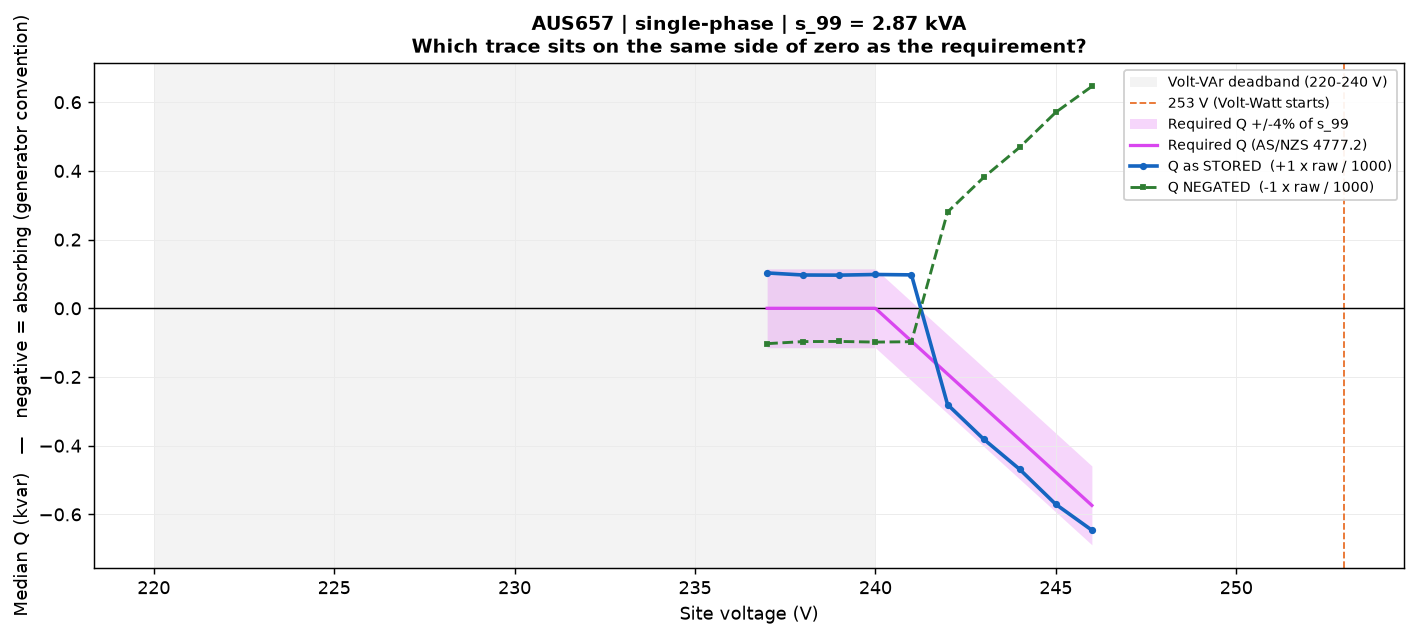

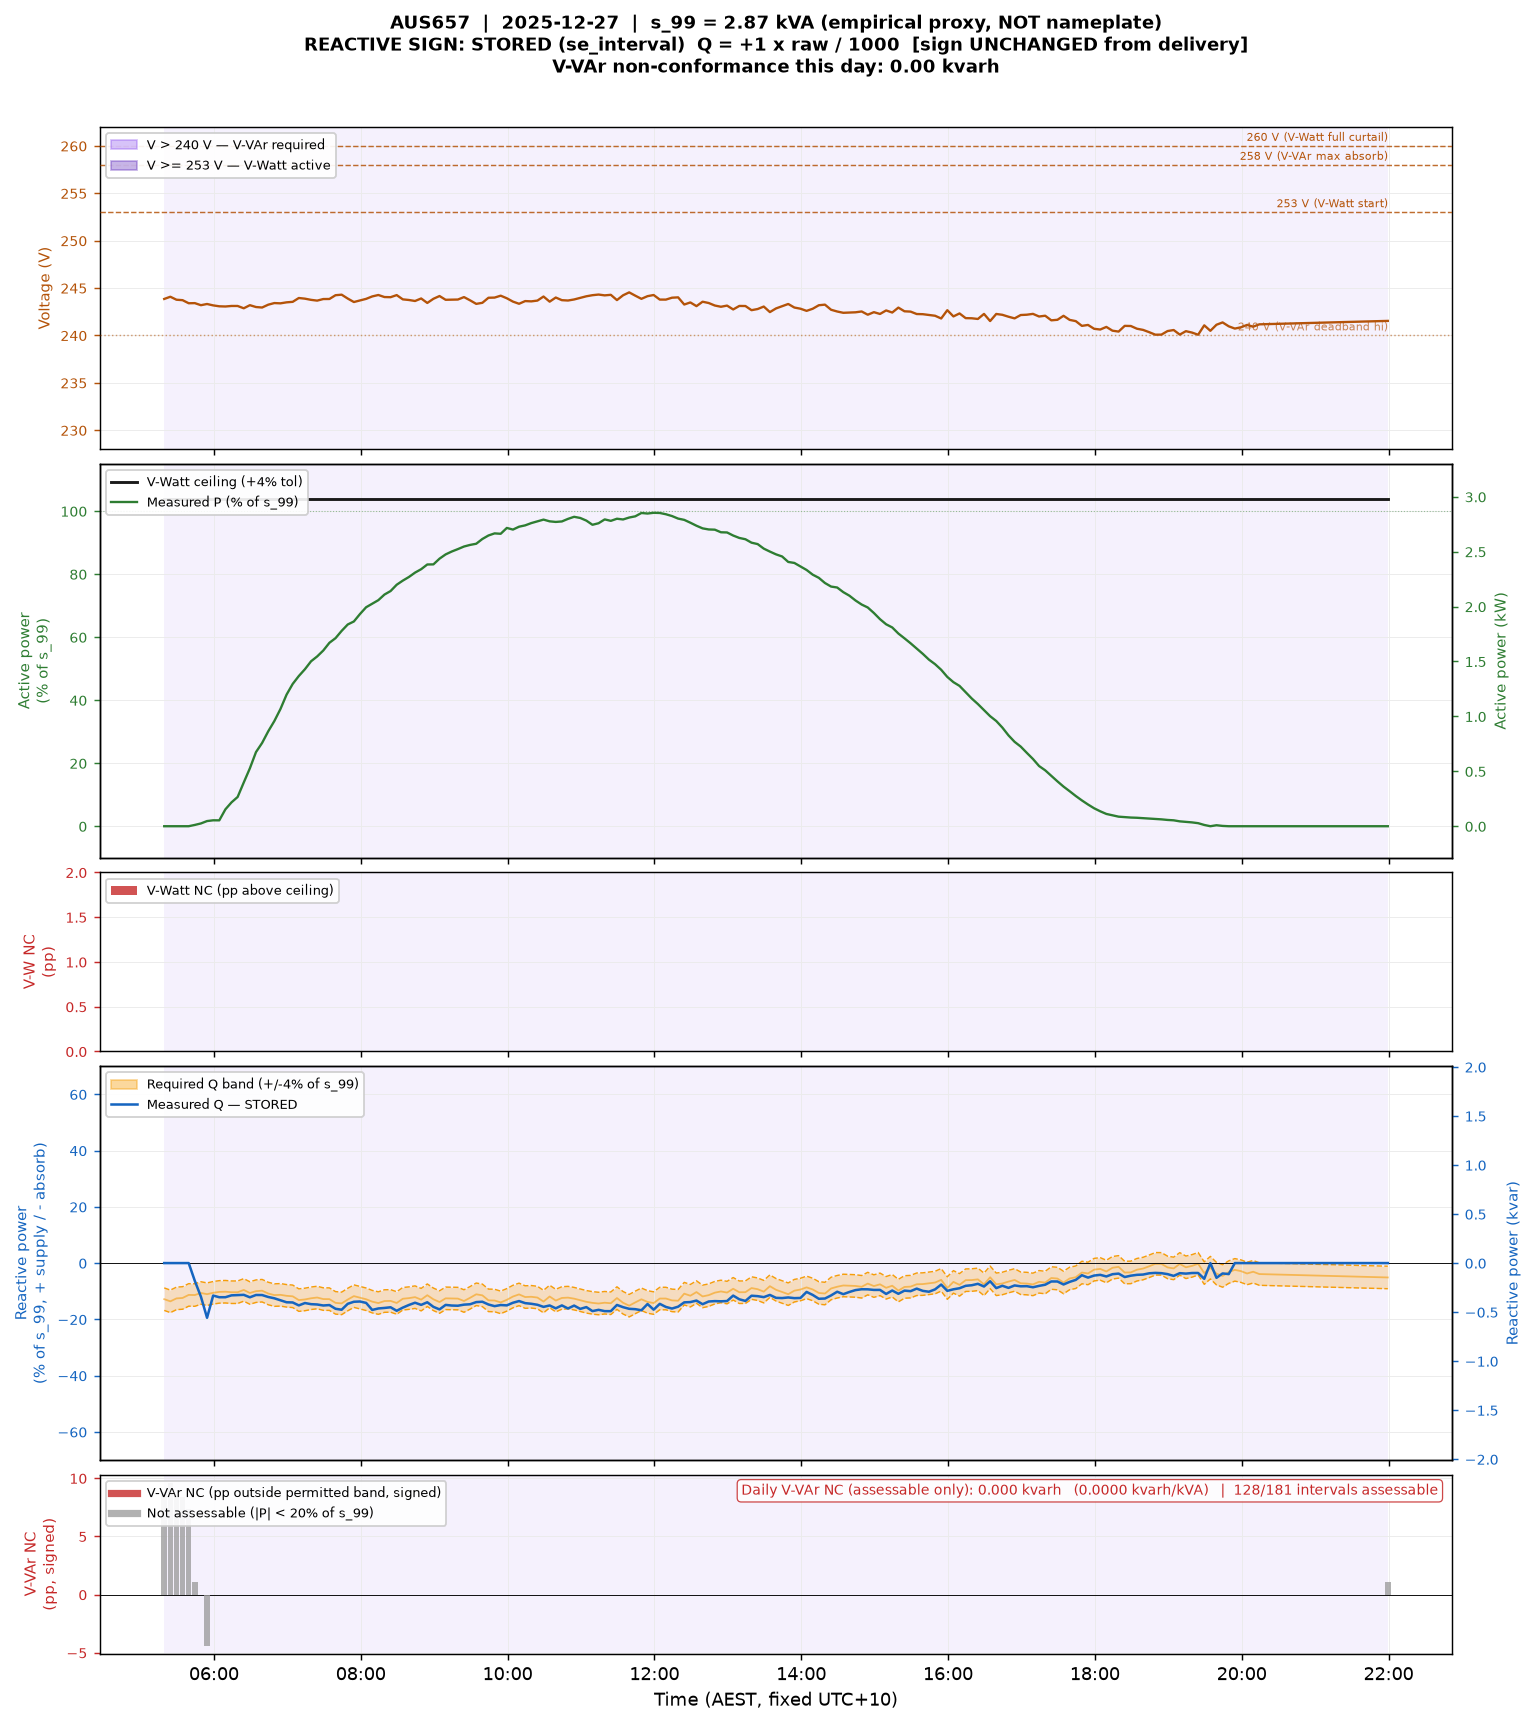

In [29]:
def explore(site, day=None, orientation="raw"):
    """Profile + curve + daily plot for one site. Returns the day frame."""
    display(ex.site_profile(con, site))
    display(ex.plot_site_voltvar_curve(ex.site_voltvar_curve(con, site), site,
                                       ex.site_profile(con, site)))
    avail = ex.site_days_available(con, site)
    day = day or str(avail.day_aest.iloc[0])[:10]
    frame = ex.site_day(con, site, day)
    display(ex.plot_operational(frame, site, float(frame.s_99.iloc[0]), day,
                                orientation=orientation))
    return frame

_ = explore(fit[fit.verdict == "stored fits (within tol)"].site_alias.iloc[0],
            orientation="stored")

### Per-timestamp categorisation

The same D9 interval scoring, restricted to one site, so the table and the plot are
guaranteed to describe the same thing.

| category | meaning |
|---|---|
| `not_assessable` | \|P\| < 20% of `s_99` — the standard sets no requirement |
| `within_band` | assessable and inside the permitted band — **this is conformance** |
| `Q_adverse` … `Q_major_surplus` | assessable and *outside* the band, split by `Q_impact` |

The five `Q_*` buckets only fire when Q is outside the band, so `within_band` and
`not_assessable` are what account for everything else. A day where the reactive trace
sits inside the amber band all afternoon should be almost entirely those two.

In [30]:
cats = ex.site_interval_categories(con, SITE, ZOOM_DATE)
display(cats.category.value_counts().rename("intervals").to_frame())
display(cats[["ts_aest", "V", "P_kW", "Q_kvar", "Q_min_permitted", "Q_max_permitted",
              "Q_impact", "category", "dist_to_band_kvar"]])

,intervals
category,
within_band,60
not_assessable,45
Q_near_conformant,22
Q_major_surplus,14


,ts_aest,V,P_kW,Q_kvar,Q_min_permitted,Q_max_permitted,Q_impact,category,dist_to_band_kvar
0,2025-04-16 05:42:37,238.419998,0.000,0.0000,-0.3284,0.3284,NaN,not_assessable,0.0
1,2025-04-16 06:07:38,237.559998,0.000,0.0000,-0.3284,0.3284,NaN,not_assessable,0.0
2,2025-04-16 06:12:38,239.360001,0.013,-0.5724,-0.3284,0.3284,NaN,not_assessable,0.0
3,2025-04-16 06:17:37,238.740005,0.016,-0.5673,-0.3284,0.3284,NaN,not_assessable,0.0
4,2025-04-16 06:22:38,239.110001,0.061,-0.5301,-0.3284,0.3284,NaN,not_assessable,0.0
...,...,...,...,...,...,...,...,...,...
136,2025-04-16 17:22:37,237.419998,0.028,-0.5443,-0.3284,0.3284,NaN,not_assessable,0.0
137,2025-04-16 17:27:37,237.550003,0.000,-0.5502,-0.3284,0.3284,NaN,not_assessable,0.0
138,2025-04-16 17:32:38,237.339996,0.000,0.0000,-0.3284,0.3284,NaN,not_assessable,0.0
139,2025-04-16 17:37:38,237.080002,0.000,0.0000,-0.3284,0.3284,NaN,not_assessable,0.0


## 4. The whole year in one figure

A single day proves nothing about an annual rate. This shows every day of the site's
year: **dates across, categories down, colour = % of that day's intervals.**

**Why it is fast.** The aggregation to (day × category) happens in DuckDB, so this
returns at most 365 × 7 = 2,555 cells rather than ~100,000 intervals. It renders in
well under a second. Do *not* fetch the intervals and pivot them client-side.

**How to read it.** A site that is genuinely fine shows a solid `within_band` row with
everything below it empty. Non-conformance appearing as a **vertical stripe** is
episodic — a handful of bad days. As a **horizontal band** it is persistent behaviour.
An annual percentage cannot tell those apart, which is exactly why this is worth
plotting before trusting a site-level verdict.

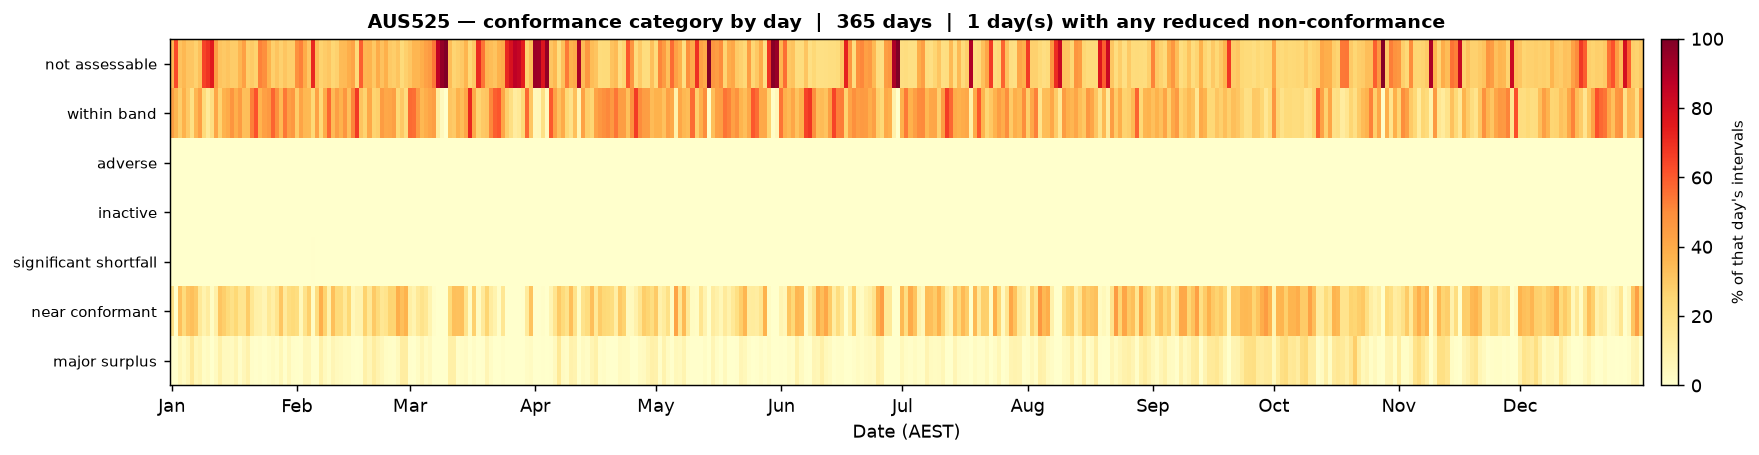

Days with ANY reduced non-conformance: 1 of 365
Worst days:


category,reduced_nonconf_pct,within_band,not_assessable
day_aest,,,
2025-02-05,0.6,24.7,71.5
2025-01-01,0.0,44.0,35.7
2025-01-02,0.0,36.5,63.5
2025-01-03,0.0,28.7,32.3
2025-01-04,0.0,37.7,35.9


In [31]:
calendar = ex.site_category_calendar(con, SITE)
display(ex.plot_category_heatmap(calendar, SITE))

reduced = calendar[["Q_adverse", "Q_inactive", "Q_significant_shortfall"]].sum(axis=1)
print(f"Days with ANY reduced non-conformance: {int((reduced > 0).sum())} of {len(calendar)}")
print(f"Worst days:")
display(calendar.assign(reduced_nonconf_pct=reduced.round(2))
        .nlargest(5, "reduced_nonconf_pct")[["reduced_nonconf_pct", "within_band",
                                             "not_assessable"]].round(1))

## What this establishes

The reactive sign is **inconsistent across the fleet**, and it does not split by phase
count. Within single-phase alone the informative sites divide almost evenly between the
two orientations.

That means **no global constant is correct** — neither the flip currently applied nor
leaving the raw value alone. `se_config.REACTIVE_POWER_SIGN` cannot express this.

It also cannot be fixed by inference. Deriving each site's orientation from whether it
absorbs above 240 V assumes the very behaviour a conformance study is measuring, and
would produce a 100% direction-conformance result by construction.

So until SolarEdge confirms the convention, or a site with known ground truth is
available:

- **magnitude conformance is assessable** — how much reactive power a site delivers
  relative to the requirement is orientation-independent;
- **direction conformance is not** — `Q_adverse` cannot be distinguished from a
  reporting-polarity difference.

The D9 Volt-VAr category results should be read with that restriction, for **both**
cohorts, not just three-phase.